In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline 

In [2]:
df = pd.read_csv("Algerian_forest_fires_dataset_CLEANED_UPDATE.csv")

In [3]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [4]:
df.columns 

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [5]:
# Drop month , day and year 

df.drop(['day','month','year'],axis=1,inplace= True)

In [6]:
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [7]:
corr = df.corr()

<Axes: >

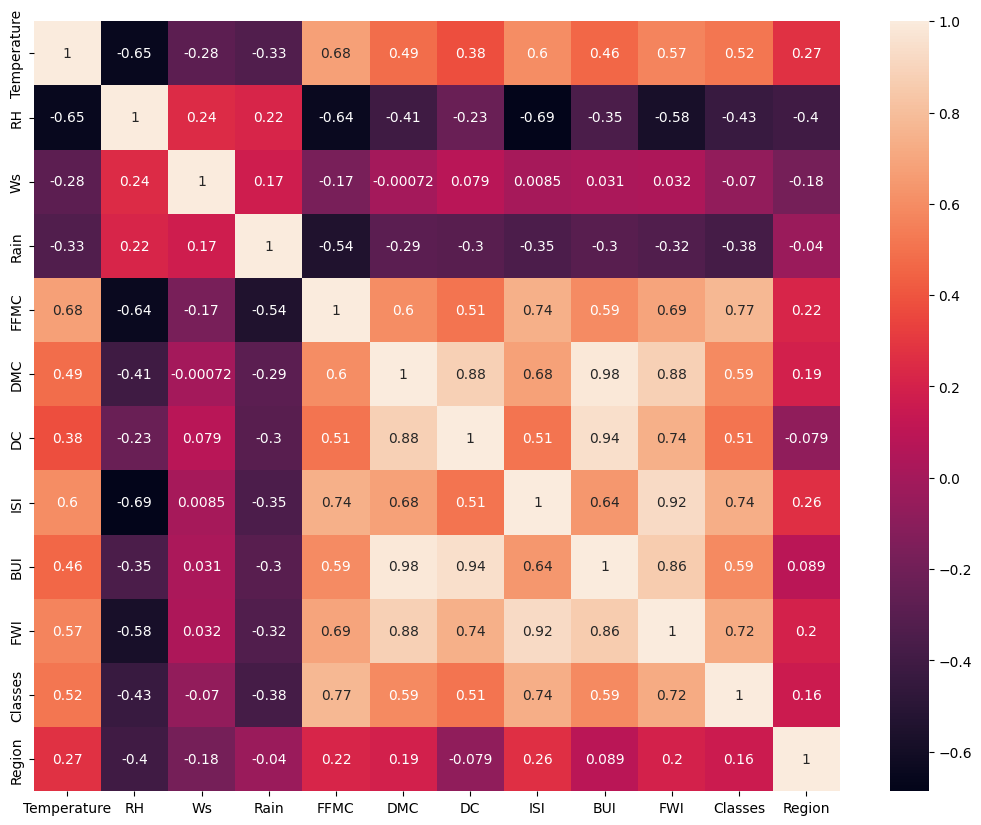

In [8]:
plt.figure(figsize=(13,10))
sns.heatmap(corr,annot=True)

In [9]:
# Sepearating our input and Output features 
X = df.drop(columns='FWI',axis=1)
y = df['FWI']

In [10]:
# train test sp;it of data. 

from sklearn.model_selection import train_test_split

X_train, X_test, y_train , y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [11]:
X_train.shape , X_test.shape

((182, 11), (61, 11))

In [12]:
y_test

24      8.4
6       7.2
152     0.5
232     3.8
238     6.5
       ... 
162     0.8
178     9.0
224     3.9
230    15.4
154     5.2
Name: FWI, Length: 61, dtype: float64

In [13]:
# Now we select all those Features which are highly positively correlated, we remove them at last 

def correlation(dataset,thershold):
    col_corr = set()
    corr = dataset.corr() # matrix created
    
    for i in range(len(corr.columns)):
        for j in range(i):
            if abs(corr.iloc[i,j]) > thershold:
                colname = corr.columns[i]
                col_corr.add(colname)
    return col_corr

In [14]:
corr_features = correlation(X_train,0.85)

In [15]:
# thershold -- Domain Expert 
# Now we remove the BUI and DC feature as in place of them we can use those features that were correlated with BUI and DC feature

In [16]:
# Drop these features when correlation is more than 0.85
X_train.drop(corr_features,axis=1,inplace=True)
X_test.drop(corr_features,axis=1,inplace=True)


# Feature Scaling or Standarization

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# BOX PLOTS to understand effects of Standard Scaler


Text(0.5, 1.0, 'After scaling')

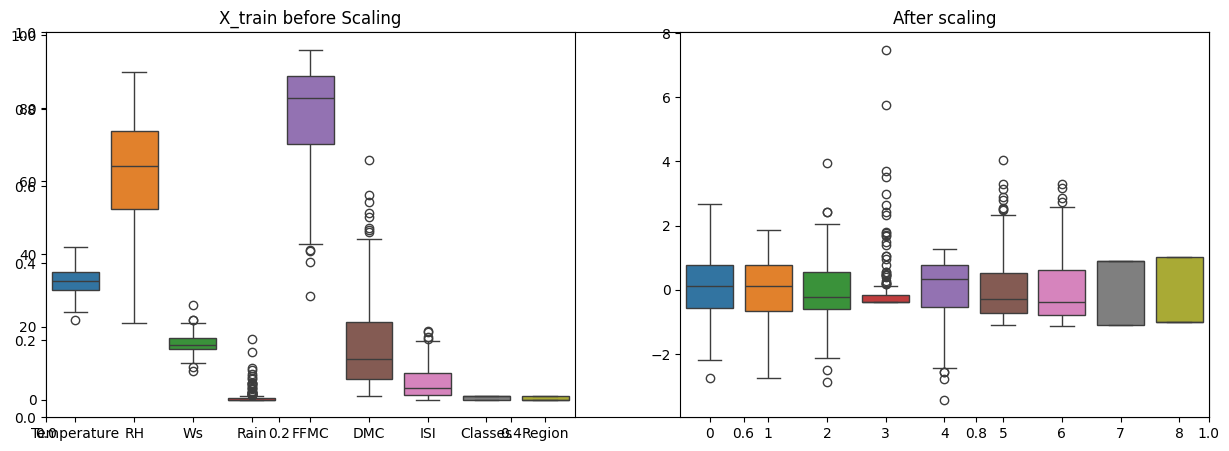

In [18]:
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data = X_train)
plt.title("X_train before Scaling")
plt.subplot(1,2,2)
sns.boxplot(data = X_train_scaled)
plt.title("After scaling")

### Observation for standard scaler 
- before scaling the points were all in diffrent units 
- now after scaling the mean of each feature is near to zero and variance is close to 1, 
- Conclusion : After standerizing the data, the outliers shift 

# MODEL TRAINING 
## APPLYING 
- Linear Regression
- RIDGE 
- LASSO 
- ELASTIC NET 

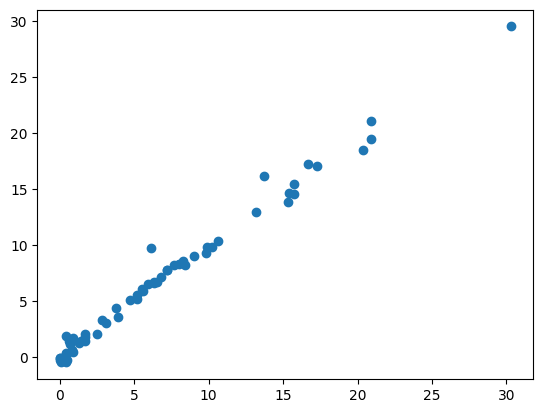

In [19]:
# Linear Regression 

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score
linreg = LinearRegression(n_jobs=-1)

linreg.fit(X_train_scaled,y_train)
y_pred_linreg = linreg.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred_linreg)
mse = mean_squared_error(y_test,y_pred_linreg)
score = r2_score(y_test,y_pred_linreg)
plt.scatter(y_test,y_pred_linreg)

In [20]:
print(f'mae : {mae}\nmse :{mse}\nR**2 Test :{score*100}')

mae : 0.5468236465249978
mse :0.674276687379158
R**2 Test :98.47657384266951


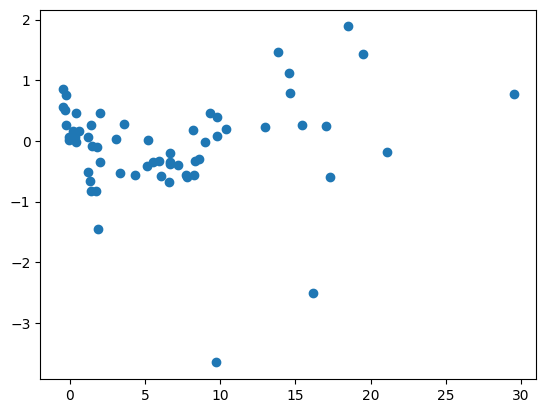

In [21]:
# checking model capability using residuals 
residual = y_test - y_pred_linreg

plt.scatter(y_pred_linreg,residual)

# Lasso Regression 

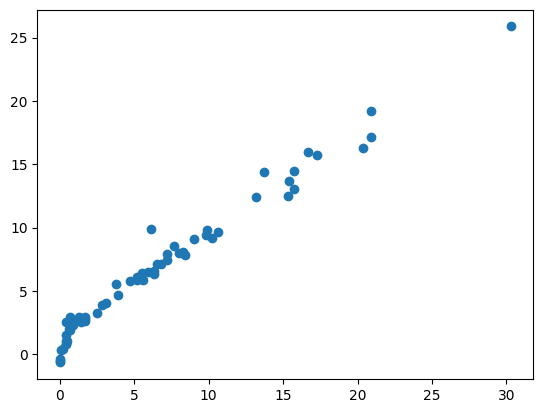

In [22]:
# Lasso Regression 

from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score
lasorig = Lasso()

lasorig.fit(X_train_scaled,y_train)
y_pred_lasso = lasorig.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred_lasso)
mse = mean_squared_error(y_test,y_pred_lasso)
score = r2_score(y_test,y_pred_lasso)
plt.scatter(y_test,y_pred_lasso)

In [23]:
print(f'mae : {mae}\nmse :{mse}\nR**2 Test :{score*100}')

mae : 1.133175994914409
mse :2.2483458918974772
R**2 Test :94.92020263112389


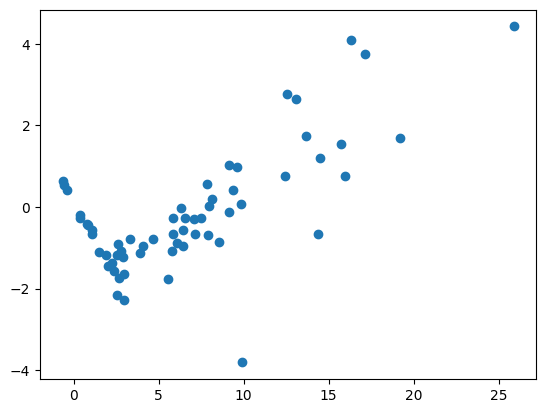

In [24]:
# checking model capability using residuals 
residual = y_test - y_pred_lasso

plt.scatter(y_pred_lasso,residual)

# Ridge Regression 

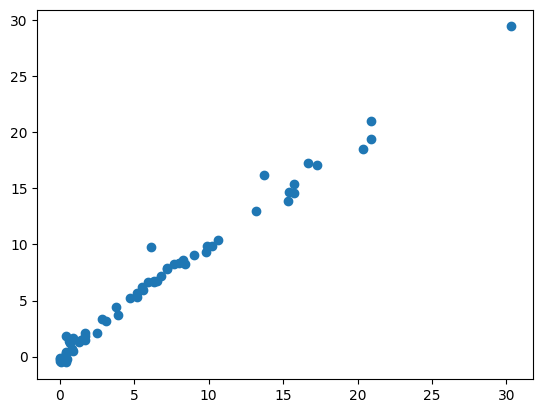

In [25]:
# Lasso Regression 

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score
ridreg = Ridge()

ridreg.fit(X_train_scaled,y_train)
y_pred_ridge = ridreg.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred_ridge)
mse = mean_squared_error(y_test,y_pred_ridge)
score = r2_score(y_test,y_pred_ridge)
plt.scatter(y_test,y_pred_ridge)

In [26]:
print(f'mae : {mae}\nmse :{mse}\nR**2 Test :{score*100}')

mae : 0.5642305340105715
mse :0.6949198918152096
R**2 Test :98.42993364555512


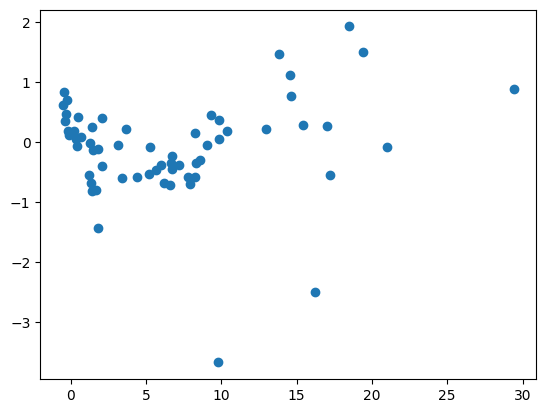

In [27]:
# checking model capability using residuals 
residual = y_test - y_pred_ridge

plt.scatter(y_pred_ridge,residual)

# Elastic Net

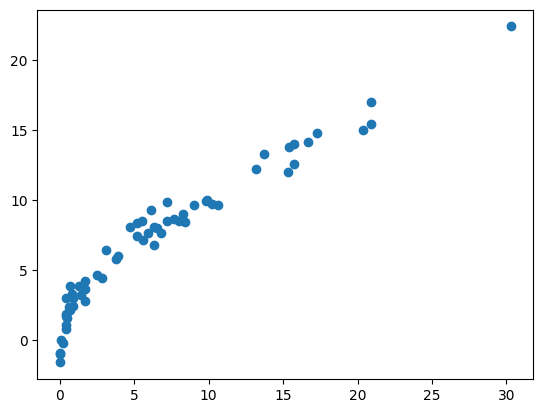

In [28]:
# Lasso Regression 

from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score
Ereg = ElasticNet()

Ereg.fit(X_train_scaled,y_train)
y_pred_Elastic = Ereg.predict(X_test_scaled)
mae = mean_absolute_error(y_test,y_pred_Elastic)
mse = mean_squared_error(y_test,y_pred_Elastic)
score = r2_score(y_test,y_pred_Elastic)
plt.scatter(y_test,y_pred_Elastic)

In [29]:
print(f'mae : {mae}\nmse :{mse}\nR**2 Test :{score*100}')

mae : 1.8822353634896005
mse :5.5172511010252245
R**2 Test :87.53460589519703


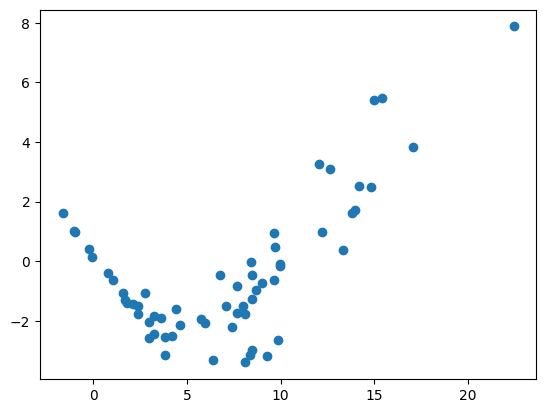

In [30]:
# checking model capability using residuals 
residual = y_test - y_pred_Elastic

plt.scatter(y_pred_Elastic,residual)

# OBSERVATIONS about Model Selection
- Each show residual pattern. 
- Maybe the data is not fit for linear models
- but when we plot the y_test vs y_pred data we get linear variation? 
- what to interprest from residuals now ??

- A good model gives a straight line in prediction plot, but a correct model gives random scatter in residual plot

# Polynomial Regression 

In [31]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline


poly = PolynomialFeatures(degree=2)

pipeline = Pipeline([
    ("poly" , PolynomialFeatures(degree=2,include_bias=True)),
    ("scaler" , StandardScaler()),
    ("model",LinearRegression())
])

pipeline.fit(X_train_scaled,y_train)

y_pred_poly = pipeline.predict(X_test_scaled)

print("********* EVALUATION METRICS ***************")
mae = mean_absolute_error(y_test,y_pred_poly)
mse = mean_squared_error(y_test,y_pred_poly)
r2 = r2_score(y_test,y_pred_poly)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"R2: {r2}")

********* EVALUATION METRICS ***************
MAE: 0.3304703527907005
MSE: 0.23823738071673642
R2: 0.9946173868349435


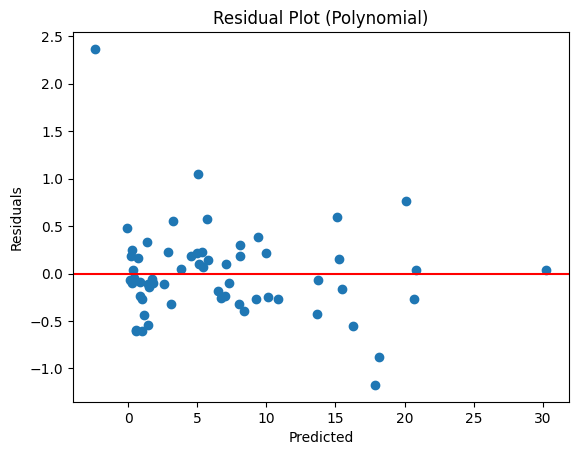

In [32]:
residual = y_test - y_pred_poly

plt.scatter(y_pred_poly, residual)
plt.axhline(y=0, color='r')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot (Polynomial)")
plt.show()

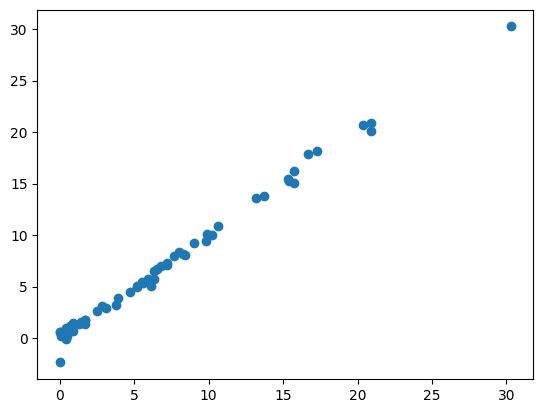

In [33]:
plt.scatter(y_test,y_pred_poly)

# CROSS VALIDATION ON LASSO MODEL 

In [35]:
from sklearn.linear_model import LassoCV
lassocv = LassoCV(cv = 5)
lassocv.fit(X_train_scaled,y_train)

,eps,0.001
,n_alphas,'deprecated'
,alphas,'warn'
,fit_intercept,True
,precompute,'auto'
,max_iter,1000
,tol,0.0001
,copy_X,True
,cv,5
,verbose,False
,n_jobs,None


In [36]:
lassocv.predict(X_test_scaled)

array([ 8.17490595,  7.68312478, -0.25676525,  4.72643402,  6.78715772,
        1.77624325,  2.23148094,  7.64057821,  1.99176323,  3.39941035,
        0.62808928,  9.95945488,  9.36168319, 16.98503659, 18.28488762,
        1.61644108,  1.62751276, -0.6415713 ,  7.28510526,  3.10926518,
        1.95541903,  0.18069335,  6.47563129,  0.14318503, 20.99597009,
        5.11755206,  5.86208849,  9.75914403, -0.77037467,  9.91838577,
        6.72277075, -0.31776007, 10.31109643, 14.4365551 ,  1.71022677,
        0.83439752,  2.03414915,  5.97488529, -0.6263644 , -0.56200288,
        6.47253729,  2.07971408,  8.46741557, -0.8464481 , 15.40443856,
        8.32941189,  8.48782486,  1.44030355, 13.02752812,  1.20911545,
       29.08623849,  5.49737681, 17.15937199, 19.28890096, 13.71102991,
       16.05355549,  0.99056448,  9.0873725 ,  3.84455993, 14.43991192,
        5.23034139])

In [37]:
lassocv.alpha_

np.float64(0.05725391318234408)

In [39]:
lassocv.alphas_

array([7.05853002, 6.58280872, 6.13914944, 5.72539132, 5.33951911,
       4.97965339, 4.64404142, 4.33104857, 4.03915039, 3.76692517,
       3.51304702, 3.27627941, 3.05546914, 2.84954075, 2.65749124,
       2.47838523, 2.31135036, 2.15557308, 2.01029467, 1.87480753,
       1.74845178, 1.63061198, 1.52071419, 1.41822315, 1.32263965,
       1.23349817, 1.15036452, 1.0728338 , 1.00052839, 0.93309613,
       0.87020857, 0.81155943, 0.75686304, 0.705853  , 0.65828087,
       0.61391494, 0.57253913, 0.53395191, 0.49796534, 0.46440414,
       0.43310486, 0.40391504, 0.37669252, 0.3513047 , 0.32762794,
       0.30554691, 0.28495408, 0.26574912, 0.24783852, 0.23113504,
       0.21555731, 0.20102947, 0.18748075, 0.17484518, 0.1630612 ,
       0.15207142, 0.14182231, 0.13226397, 0.12334982, 0.11503645,
       0.10728338, 0.10005284, 0.09330961, 0.08702086, 0.08115594,
       0.0756863 , 0.0705853 , 0.06582809, 0.06139149, 0.05725391,
       0.05339519, 0.04979653, 0.04644041, 0.04331049, 0.04039